In [1]:
import pandas as pd
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()
db_url = os.getenv("DATABASE_URL")
engine = create_engine(db_url)

# Шаг 1. Когортный анализ клиентов

## Импорт данных из БД

In [2]:
cohort_analysis = """
-- Формируем таблицу с датой регистрацией
with reg_dt_client as (
	select
		client_uuid,
		min(reg_date::date) as data_reg
	from public.raw_clients
	where reg_date is not null -- отсекаем клиентов без даты регистрации
	group by client_uuid -- группируем по ID клиента для того чтобы вытащить первую дату регистрации
),
-- Добавляем дату каждой покупки и сумму покупки по каждому клиенту
client_transactions as (
	select
		r.client_uuid,
		r.data_reg,
		rt.trans_date::date as trans_date,
		nullif(amount, 'error')::numeric as amount
		from reg_dt_client r
		left join public.raw_transactions rt on r.client_uuid = rt.client_uuid
),
-- Формируем таблицу "жизненного цикла"
client_lifecycle as (
	select
		client_uuid,
		date_trunc('month',data_reg):: date as cohort_month, -- Определяем когорту каждого клиента
		coalesce(
		(extract(year from trans_date)*12 + extract(month from trans_date)) -
		(extract(year from data_reg)*12 + extract(month from data_reg)),
		0) as month_life, -- Определяем жизненный цикл
		amount
	from client_transactions
),
-- Создаём таблицу с агрегированными данными по каждой когорте
cohort_aggregated as (
	select
		cohort_month,
		month_life,
		sum(amount) as total_amount,
		count(distinct(client_uuid)) as number_of_users
		from client_lifecycle
		group by cohort_month,month_life
 )
 -- Формируем финальную таблицу для когортного анализа добавляя метрики (retention,ltv)
select
	cohort_month,
	month_life,
	total_amount,
	number_of_users,
	round(number_of_users * 100.0 / first_value(number_of_users) over (partition by cohort_month order by month_life asc),2) as retention,
	round(sum(total_amount) over (partition by cohort_month order by month_life asc) / first_value(number_of_users) over (partition by cohort_month order by month_life asc),0) as ltv
from cohort_aggregated
order by cohort_month
"""
df = pd.read_sql(cohort_analysis, engine)
df['month_life'] = df['month_life'].astype(int)

## Визуализация матрицы удержания. Построения тепловой карты Retention Rate

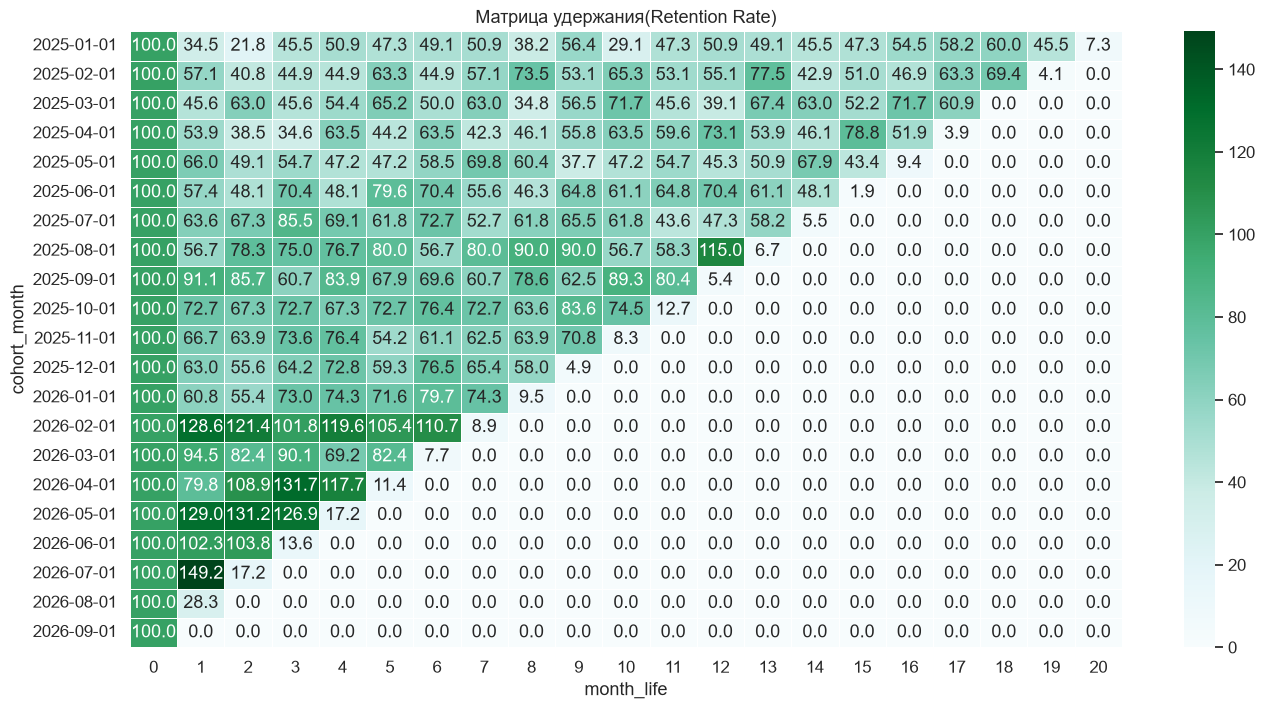

In [13]:
# Визуализация матрицы удержания
# Построение сводной таблицы для retention (матрица удержания)
pivot_cohort = df.pivot_table(
    index='cohort_month',
    columns='month_life',
    values='retention',
    fill_value=0
)

plt.figure(figsize=(16, 8))
sns.set_theme(style='white', font_scale=1.1)

sns.heatmap(
    pivot_cohort,
    annot=True,
    fmt='.1f',
    cmap='BuGn',
    linewidths=0.5,
    cbar=True,
)
plt.title('Матрица удержания(Retention Rate)')
plt.show()

### Вывод:
### На графике четко отслеживается аномальная доля RR превышающая 100% (пример ``25-08-01,26-02-01,26-04-01``)
**Гипотеза:**
1. В таблице public.raw_clients одно и то же значение client_uuid дублируется с разными датами регистрации, либо в таблицу транзакций public.raw_transactions попадают покупки от «гостей» или старых клиентов под удаленными/измененными ID, которых не было в исходной таблице клиентов за этот месяц. База данных просто не находит их в числе «новорожденных» января, но видит их покупки, из-за чего числитель становится больше знаменателя.
2.  Аномальные пики в определенные месяцы

**Задача**
1. - [x] Провести анализ даты регистрации пользователей в таблице raw_clients
2. - [X] Проверить "Сиротские" транзакции. Проверить, есть ли в базе транзакции от клиентов, которых вообще нет в таблице регистраций

### Проверка дублей в таблице регистрации клиентов

In [4]:
duplicate_registrations = """
select
	client_uuid,
	count(*)
from public.raw_clients
group by client_uuid
having count(*) > 1"""

duplicate_reg = pd.read_sql(duplicate_registrations, engine)
client_counts = duplicate_reg['count'].value_counts()
client_counts

count
2    1629
3     576
4     163
5      40
6       5
Name: count, dtype: int64

In [5]:
raw_clients = """
select
	*
from public.raw_clients
"""
raw_clients = pd.read_sql(raw_clients, engine)
raw_clients.head(5)

,client_uuid,full_name,phone,email,reg_date,source,app_version
0,cfc38707-8962-4619-9213-446a0716ebf3,Monique Vincent,388-692-6745,courtneyzimmerman@example.org,2026-08-28T04:45:38,NaN,3.2
1,83351004-6f1c-429c-a151-564e83423f3d,Ronnie Romero,609-456-1272,ljohnson@example.com,2026-04-24T17:10:41,google,3.1
2,8dc98cf2-6956-4eda-a326-3d36b8f28819,Carrie Watson,+1-340-455-4074x54186,jane62@example.net,2026-07-13T08:24:18,fb,4.0
3,1753bffc-d559-49ad-bb86-bc2071346892,Jordan Knapp,746-308-5960x389,michaelmayer@example.net,2026-01-13T00:36:54,fb,NaN
4,b4d9d34e-87d5-40e4-90e2-0ce0fbcb3d20,Jennifer Terrell,001-967-600-1984x46224,racheltaylor@example.com,2025-08-14T12:13:31,organic,3.2


In [6]:
unique_users = raw_clients['client_uuid'].nunique()
duplicate_count = raw_clients['client_uuid'].duplicated().sum()
print(f'Количество уникальных пользователей: {unique_users}')
print(f'Количество дублей: {duplicate_count}')
print(f'Всего строк в таблице: {unique_users+duplicate_count}')

Количество уникальных пользователей: 5345
Количество дублей: 3455
Всего строк в таблице: 8800


### Поиск транзакций без регистрации

In [7]:
transactions = """
select
	rt.client_uuid,
	rt.trans_date,
	rc.client_uuid as reg_client
from public.raw_transactions rt
left join public.raw_clients rc on rc.client_uuid = rt.client_uuid
"""
transactions = pd.read_sql(transactions, engine)
transactions.head(5)

,client_uuid,trans_date,reg_client
0,e7e5b924-4109-48d3-adc0-d99ae6505492,2026-03-03T01:31:16,e7e5b924-4109-48d3-adc0-d99ae6505492
1,e7e5b924-4109-48d3-adc0-d99ae6505492,2026-03-03T01:31:16,e7e5b924-4109-48d3-adc0-d99ae6505492
2,3135776d-fa9e-41f3-9bd4-1934533425af,2026-09-02T18:25:03,NaN
3,26f71ab8-3642-4b93-8f3a-71b0b0c7f6f6,2025-06-12T03:04:23,26f71ab8-3642-4b93-8f3a-71b0b0c7f6f6
4,26f71ab8-3642-4b93-8f3a-71b0b0c7f6f6,2025-06-12T03:04:23,26f71ab8-3642-4b93-8f3a-71b0b0c7f6f6


In [8]:
registered_transactions = transactions['reg_client'].count().sum()
guest_transactions = transactions['reg_client'].isna().sum()
total_count_transactions = registered_transactions + guest_transactions
print(f'Всего транзакций: {total_count_transactions}')
print(f'Количество транзакций совершенных зарегистрированными пользователями: {registered_transactions}')
print(f'Количество транзакций без регистрации: {guest_transactions}')

Всего транзакций: 21712
Количество транзакций совершенных зарегистрированными пользователями: 16805
Количество транзакций без регистрации: 4907


**Вывод**: Анализ причин аномалии
На графике удержание (RR) превышает 100%. Проверка гипотез в данных показала, что это не ошибка в коде, а проблемы в исходных таблицах:
1. Дубликаты в регистрациях (raw_clients):
В базе обнаружено 3 455 дублей. Около 2,5 тысяч клиентов зарегистрированы по 2 и более раз под одним ID, но с разными датами. Из-за этого мы неправильно считали количество пришедших в конкретный месяц людей (занижали знаменатель формулы).
2. Покупки без регистрации (raw_transactions):
Каждая четвертая покупка в базе (4 907 транзакций) совершена «гостями», которых вообще нет в таблице регистраций. В пиковые месяцы продаж эти люди делали много покупок, раздувая числитель формулы, из-за чего удержание и пробивало потолок в 100%.


Что делаем дальше (План):
Считать удержание от «грязной» даты регистрации бессмысленно. Поэтому мы переходим на модель Paying Retention — будем собирать когорты по дате первой покупки. Это автоматически решит обе проблемы: дубликаты отсекутся, а все платящие «гости» займут свои правильные места.

# Шаг 2. Новый когортный анализ по дате первой покупки

In [9]:
new_cohort = """
with ffirst_purchase as (
-- Формируем таблицу с первой покупкой каждого клиента
	select
		client_uuid,
		min(date_trunc('month', trans_date::date)::date) as cohort_month
	from raw_transactions
group by client_uuid
),
-- Собираем жизненный цикл (все покупки клиентов)
client_lifecycle as (
	select
		fp.cohort_month,
		rt.client_uuid,
		rt.trans_date :: date as trans_date,
		nullif(amount,'error'):: numeric as amount,
		(extract(year from rt.trans_date :: date) * 12 + extract(month from rt.trans_date :: date)) -
		(extract(year from fp.cohort_month) * 12 + extract(month from fp.cohort_month)) as month_life
	from raw_transactions rt
	inner join ffirst_purchase fp on fp.client_uuid  = rt.client_uuid
),
-- Создаём таблицу с агрегированными данными по каждой когорте
cohort_aggregated as (
	select
		cohort_month,
		month_life,
		sum(amount) as total_amount,
		count(distinct(client_uuid)) as number_of_users
	from client_lifecycle
	group by cohort_month, month_life
)
-- Формируем финальную таблицу для когортного анализа добавляя метрики (retention,ltv)
select
	cohort_month,
	month_life,
	total_amount,
	number_of_users,
	round(number_of_users * 100.0 / first_value(number_of_users) over (partition by cohort_month order by month_life),2) as retention,
	round(sum(total_amount) over (partition by cohort_month order by month_life) / first_value(number_of_users) over (partition by cohort_month order by month_life),0) as ltv
from cohort_aggregated
"""
df_new_cohort = pd.read_sql(new_cohort, engine)
df_new_cohort['month_life'] = df_new_cohort['month_life'].astype(int)
df_new_cohort['ltv'] = df_new_cohort['ltv'].astype(int)
df_new_cohort.head(3)

,cohort_month,month_life,total_amount,number_of_users,retention,ltv
0,2025-01-01,0,86242.66,16,100.00,5390
1,2025-01-01,3,8310.28,1,6.25,5910
2,2025-01-01,4,48317.98,5,31.25,8929


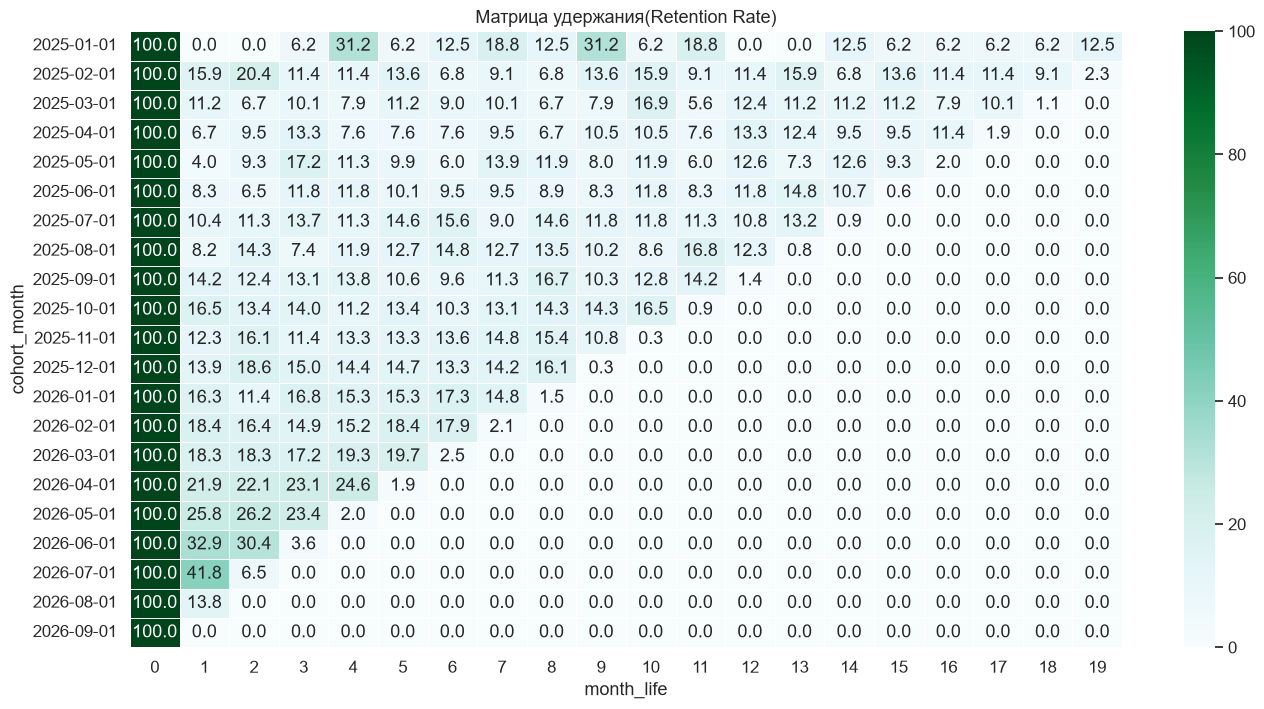

In [10]:
# Визуализация матрицы удержания
# Построение сводной таблицы для retention (матрица удержания)
pivot_cohort_rr = df_new_cohort.pivot_table(
    index='cohort_month',
    columns='month_life',
    values='retention',
    fill_value=0
)

plt.figure(figsize=(16, 8))
sns.set_theme(style='white', font_scale=1.1)

sns.heatmap(
    pivot_cohort_rr,
    annot=True,
    fmt='.1f',
    cmap='BuGn',
    linewidths=0.5,
    cbar=True,
)
plt.title('Матрица удержания(Retention Rate)')
plt.show()

**Итоговый вывод**: Анализ удержания клиентов (Paying Retention)
Переход на расчет когорт по дате первой покупки полностью исправил математику метрики: удержание в стартовый месяц (month_life = 0) строго равно 100%, а показатели последующих месяцев плавно затухают без аномальных вылетов за рамки 100%.
Анализ финальной матрицы выявил три ключевых инсайта:
1. Рост качества продукта и маркетинга: Качество привлекаемых когорт стабильно и резко улучшается. Если в начале 2025 года удержание клиентов на 1-й месяц жизни (month_life = 1) составляло всего 3.9% – 15.9%, то к середине 2026 года этот показатель вырос до 21.9% – 41.8%. Клиенты из новых когорт возвращаются за повторными покупками в 3–4 раза активнее.
2. Сезонные пики активности (Эффект распродаж): На графике четко прослеживаются две вертикальные «диагонали» возвращаемости, привязанные к календарным месяцам:
	• Январь 2026 года (всплески на month_life = 12 для первой когорты, month_life = 10 для третьей и т.д.) — в этот период синхронно «проснулись» и совершили покупки клиенты всех существующих когорт.
	• Август 2026 года (всплески на последних доступных месяцах жизни для когорт конца 2025 – начала 2026 года). Это указывает на сильные сезонные триггеры (акции, распродажи), эффективно возвращающие старую базу.
3. Статистический шум первой когорты: Когорта 2025-01-01 имеет аномально скачущие показатели (0% -> 31.25% -> 12.5%). Все ее значения кратны числу 16 (1/16 = 6.25%). Это говорит о том, что размер базовой когорты критически мал (всего 16 человек), и ее поведение не репрезентативно для бизнес-выводов.
Общий итог: Новая модель расчетов дала чистую коммерческую картину. Продукт демонстрирует отличную динамику удержания, а вовлеченность новой аудитории со временем кратно выросла.

# Шаг 3. Анализ LTV

In [11]:
df_new_cohort.head(3)

,cohort_month,month_life,total_amount,number_of_users,retention,ltv
0,2025-01-01,0,86242.66,16,100.00,5390
1,2025-01-01,3,8310.28,1,6.25,5910
2,2025-01-01,4,48317.98,5,31.25,8929


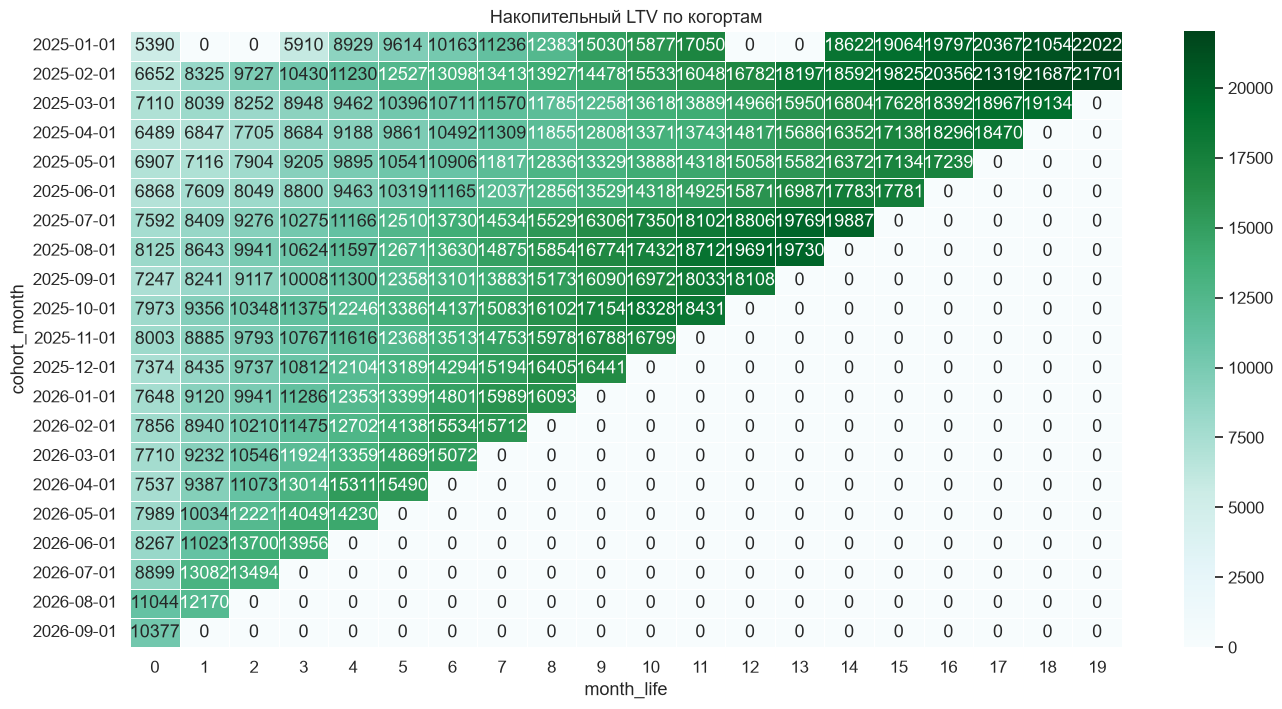

In [12]:
pivot_ltv = df_new_cohort.pivot_table(
    index='cohort_month',
    columns='month_life',
    values='ltv',
    fill_value=0
)

plt.figure(figsize=(16, 8))
sns.set_theme(style='white', font_scale=1.1)

sns.heatmap(
    pivot_ltv,
    annot=True,
    fmt='.0f',
    cmap='BuGn',
    linewidths=0.5,
    cbar=True,
)
plt.title('Накопительный LTV по когортам')
plt.show()

1. Что было сделано (Проблема и решение)
- Изначально мы считали когорты по дате регистрации клиентов. Из-за этого графики ломались, и удержание (Retention) в некоторые месяцы превышало 100%.
Мы проверили сырые данные и нашли причину: в базе было 3 455 дубликатов регистраций клиентов, а каждая четвертая покупка (22.6%) совершалась «гостями» без регистрации.
Решение: Мы полностью переписали логику и перешли на модель Paying Retention — теперь мы объединяем клиентов в когорты строго по дате их самой первой покупки. Это полностью очистило данные от ошибок.
2. Главные выводы по удержанию клиентов (Retention)
- Клиенты стали лояльнее: Новые клиенты возвращаются в продукт гораздо лучше старых. В начале 2025 года на второй месяц возвращалось всего 4–15% клиентов, а в середине 2026 года возвращаются уже 22–41%. Продукт стал удерживать людей в 3–4 раза эффективнее.
- Влияние распродаж: На графике четко видны две полосы массового возврата клиентов — в январе 2026 года и в августе 2026 года. В эти месяцы (скорее всего, из-за крупных акций) начали активно покупать клиенты из абсолютно всех прошлых когорт.
3. Главные выводы по деньгам (Накопительный LTV)
- Растет средний чек: Базовый чек первой покупки (в месяц 0) вырос. В 2025 году он составлял 5 000 – 8 000 рублей, а в 2026 году вырос до 10 000 – 11 000 рублей.
- Новые когорты приносят больше денег: За счет хорошего удержания новые клиенты окупаются в два раза быстрее. Например, к 4-му месяцу жизни клиент начала 2025 года приносил в среднем 8 929 рублей, а клиент начала 2026 года принес уже 14 233 рубля.

**Итог исследования**: Изменение логики расчета на "по первой покупке" дало нам чистые и честные графики. Продуктовые показатели бизнеса стабильно и уверенно растут: новые клиенты приходят с более высоким чеком и возвращаются за покупками в разы чаще.